In [99]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

In [100]:
batch_size = 32
lr = 0.001
epochs = 100

In [101]:
# Get dataset info - 50000 32x32 images, 10 classes

# dataset = torchvision.datasets.CIFAR10(root='/content/gdrive/MyDrive/Colab Notebooks', download=True)

# print("Number of classes: ", len(dataset.classes))
# print("Number of images: ", len(dataset))
# print("Shape of images: ", dataset[0][0].size)

import torchvision.transforms as transforms
import torchvision

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0), ratio=(0.9, 1.1)), 
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10), 
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


Files already downloaded and verified
Files already downloaded and verified


In [102]:
class Stem(nn.Module):
    def __init__(self, channels):
        super(Stem, self).__init__()
        self.conv = nn.Conv2d(channels, 64, kernel_size=3, stride=1, padding=1)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

In [103]:
class Block(nn.Module):
    def __init__(self, channels, outputs, r, k):
        super(Block, self).__init__()
        self.k = k
        self.r = r

        # Expert Branch
        self.eb = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(channels, channels // self.r),
            nn.ReLU(),
            nn.Linear(channels // r, k),
            nn.Softmax(dim=1)
        )

        # Define the K convolutional layers
        self.convolutions = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, outputs, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(outputs),
                nn.ReLU()
            ) for _ in range(self.k)])


    def forward(self, x):
        a = self.eb(x)

        # Apply each convolution to the input
        convolutional_outputs = torch.stack([conv(x) for conv in self.convolutions], dim=1)

        a = a.view(-1, self.k, 1, 1, 1)
        O = (a * convolutional_outputs).sum(dim=1)

        return O

In [104]:
class Backbone(nn.Module):
    def __init__(self, channels):
        super(Backbone, self).__init__()
        self.blocks = nn.ModuleList()
        self.channels = channels

        self.conv_arch = ((1, 64, 2), (1, 128, 2), (2, 256, 3), (2, 512, 4), (2, 512, 5))

        for i, (num_convs, out_channels, divisor) in enumerate(self.conv_arch):
            self.blocks.append(Block(channels=self.channels, outputs=out_channels,
                                    r=divisor, k=num_convs))
            self.channels = out_channels


    def forward(self, x):
        out = x
        for block in self.blocks:
            out = block(out)
        return out

In [105]:
class Classifier(nn.Module):
    def __init__(self, outputs):
        super(Classifier, self).__init__()
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.last = nn.Sequential(
            nn.Linear(outputs, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10))

    def forward(self, x):
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.last(x)
        return x

In [106]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.stem = Stem(3)
        self.backbone = Backbone(64)
        self.classifier = Classifier(512)

    def forward(self, x):
        x = self.stem(x)
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [107]:
model = Model()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [108]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, epochs)

In [113]:
train_losses = []
train_accuracies = []
test_accuracies = []
test_losses = []  

patience = 0
prev_loss = 100

def check_metrics(model, dataloader, device, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# Create a function to plot the graphs
def plot_metrics():
    plt.figure(figsize=(12, 6))

    # Plot loss (training and test loss)
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
    plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test Loss', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.legend()

    # Plot accuracy (training and test accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', color='orange')
    plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, label='Test Accuracy', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Test Accuracy')
    plt.legend()

    # Display the plots
    plt.tight_layout()
    plt.show()


# Start training
for epoch in range(epochs):
    model.train()
    correct = 0.0
    total = 0.0
    running_loss = 0.0
    tepoch = tqdm(trainloader, unit="batch")
    tepoch.set_description(f"Epoch {epoch + 1}")

    for i, data in enumerate(tepoch):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        average_loss = running_loss / (i + 1)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        accuracy = 100.0 * correct / total

        tepoch.set_postfix(loss=average_loss, acc=f"{accuracy:.3f}%")

    train_losses.append(running_loss / len(trainloader)) 
    train_accuracies.append(accuracy) 

    test_loss, test_accuracy = check_metrics(model, testloader, device, criterion)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    if prev_loss < test_loss:
        patience += 1
    else:
        patience = 0
    if patience >= 5:
        break
    prev_loss = test_loss

    scheduler.step()

    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / len(trainloader):.3f} test_accuracy: {test_accuracy:.2f}% training_accuracy: {accuracy:.2f}%')
    running_loss = 0.0

plot_metrics()
print('Finished Training')


Epoch 1: 100%|██████████| 1563/1563 [00:20<00:00, 76.42batch/s, acc=33.716%, loss=1.79]


[1,  1563] loss: 1.788 test_accuracy: 51.74% training_accuracy: 33.72%


Epoch 2: 100%|██████████| 1563/1563 [00:20<00:00, 76.67batch/s, acc=42.212%, loss=1.58]


[2,  1563] loss: 1.581 test_accuracy: 55.22% training_accuracy: 42.21%


Epoch 3: 100%|██████████| 1563/1563 [00:20<00:00, 75.54batch/s, acc=47.818%, loss=1.45]


...

Epoch 86: 100%|██████████| 1563/1563 [00:20<00:00, 78.01batch/s, acc=88.416%, loss=0.344]


[86,  1563] loss: 0.344 test_accuracy: 90.65% training_accuracy: 88.42%


Epoch 88: 100%|██████████| 1563/1563 [00:20<00:00, 76.61batch/s, acc=88.414%, loss=0.34] 


[88,  1563] loss: 0.340 test_accuracy: 90.98% training_accuracy: 88.41%


Epoch 89:  95%|█████████▍| 1480/1563 [00:18<00:01, 77.05batch/s, acc=88.430%, loss=0.34] IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



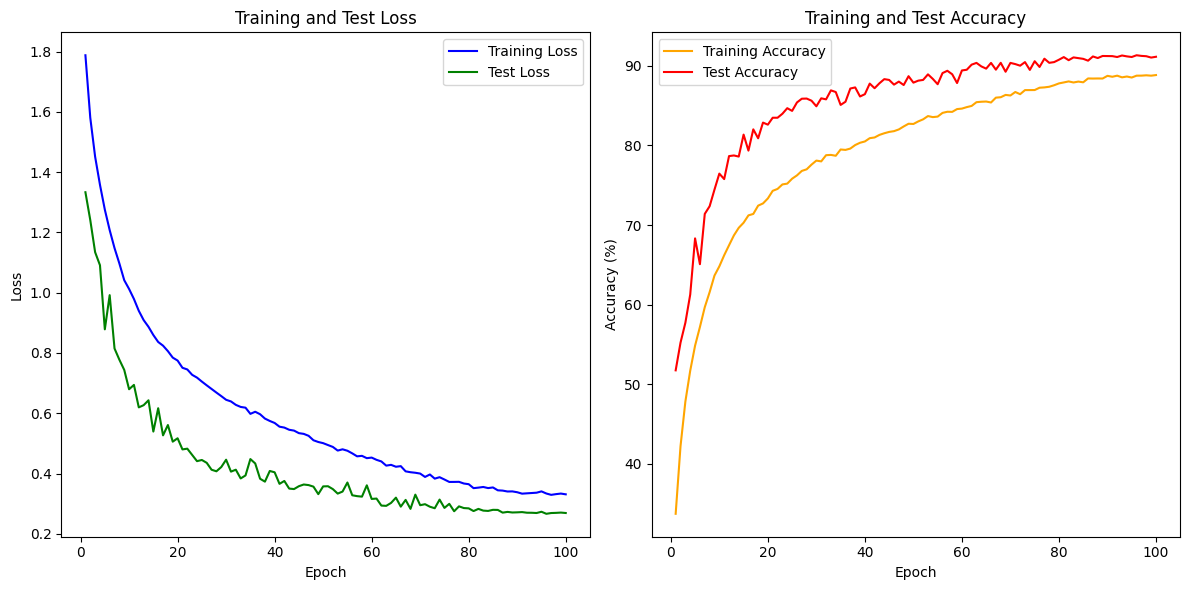

In [114]:
plot_metrics()

Average Accuracy of last 10 epochs: